# 1. Chargement et aperçu du dataset

In [1]:
import pandas as pd
df = pd.read_csv('insurance-data.csv')
df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


# 2. EDA (Analyse Exploratoire)

## 2.1 Structure, types, valeurs manquantes et doublons

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [3]:
# Statistiques descriptives
df.describe()

,age,bmi,children,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


In [4]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(1)

In [6]:
# Identifier la ligne en doublon
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,expenses
581,19,male,30.6,0,no,northwest,1639.56


In [7]:
# supprimer la ligne 
df = df.drop_duplicates()
df.duplicated().sum()
print(df.shape)

(1337, 7)


## 2.2 Distributions (histogrammes)

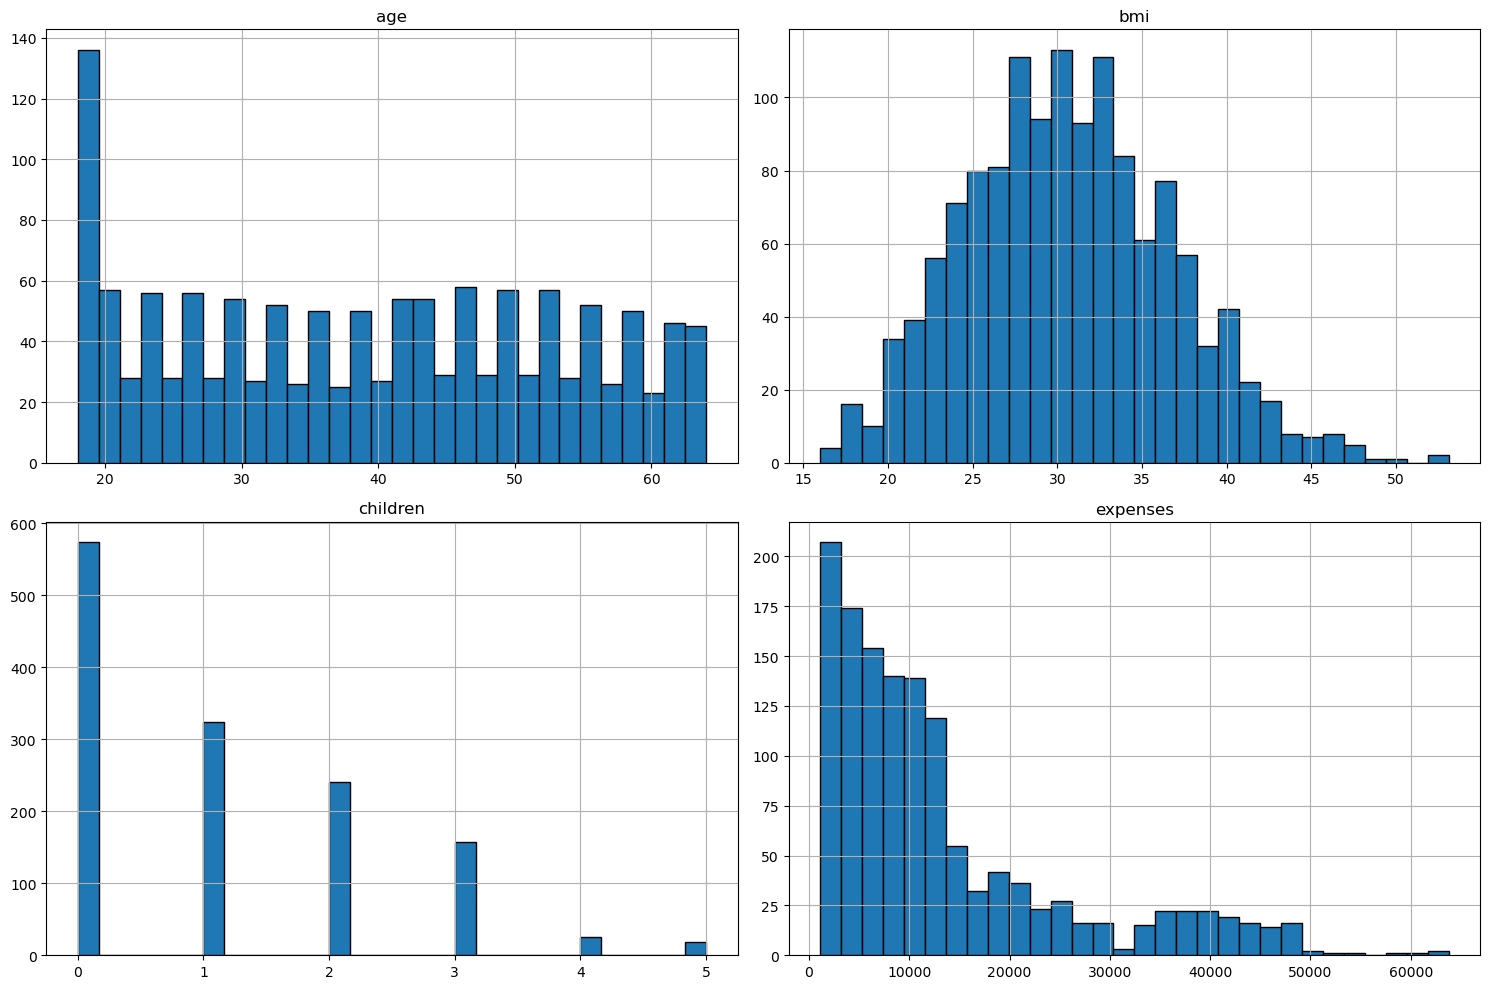

In [8]:
import matplotlib.pyplot as plt

df.hist(bins=30, figsize=(15, 10), edgecolor='black')
plt.tight_layout()
plt.show()

### Commentaire :
- Les distributions des variables numériques présentent des profils variés. L'âge est réparti de façon relativement homogène entre 18 et 64 ans, avec un pic net autour de 18 et 19 ans.
- la majorité des assurés n'a aucun enfant.
- La distribution de l'IMC (bmi) est relativement symétrique.
- Les frais médicaux (expenses) est la variable cible, présentent à l'inverse une distribution très asymétrique à droite.

## 2.3 Tendances métiers : surcoût tabagisme et IMC 

###  impact du tabagisme sur les frais

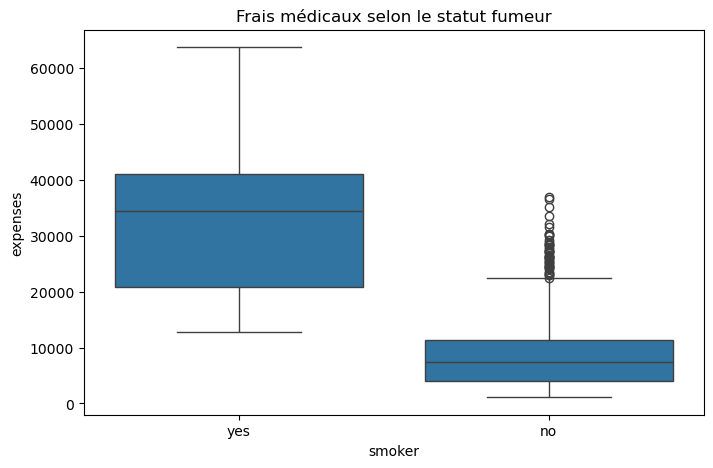

smoker
no      8440.660461
yes    32050.231971
Name: expenses, dtype: float64

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(x='smoker', y='expenses', data=df)
plt.title("Frais médicaux selon le statut fumeur")
plt.show()

df.groupby('smoker')['expenses'].mean()

### Commentaire :
Le statut fumeur a un impact considérable sur les frais médicaux. Les deux sous-populations (fumeurs et non-fumeurs) ont des profils de coûts suffisamment distincts. Le tabagisme apparaît ainsi comme un facteur de risque majeur, cohérent avec les connaissances médicales générales sur les effets du tabac sur la santé.

### Lien IMC (bmi) et frais

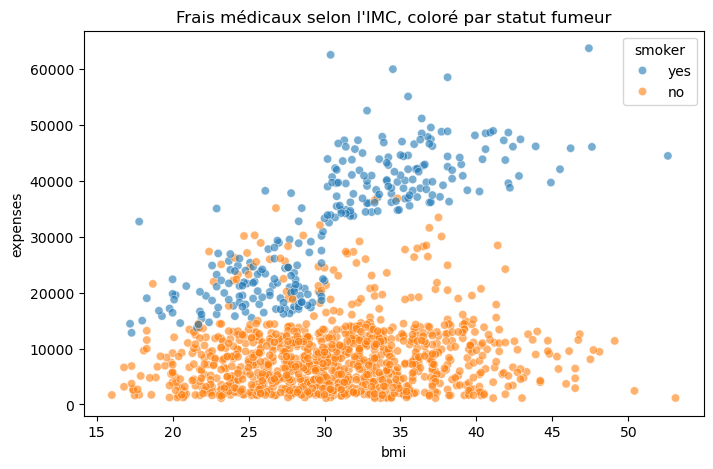

In [10]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='bmi', y='expenses', hue='smoker', data=df, alpha=0.6)
plt.title("Frais médicaux selon l'IMC, coloré par statut fumeur")
plt.show()

### Commentaire : Ce graphique révèle une relation claire entre l'IMC, le statut fumeur et les frais médicaux.
- Chez les non-fumeurs (points orange), les frais restent globalement bas et relativement stables quel que soit l'IMC.
- Chez les fumeurs (points bleus), on distingue nettement deux groupes : ceux avec un IMC inférieur et d'autres supérieures. 


## 2.4 Corrélations

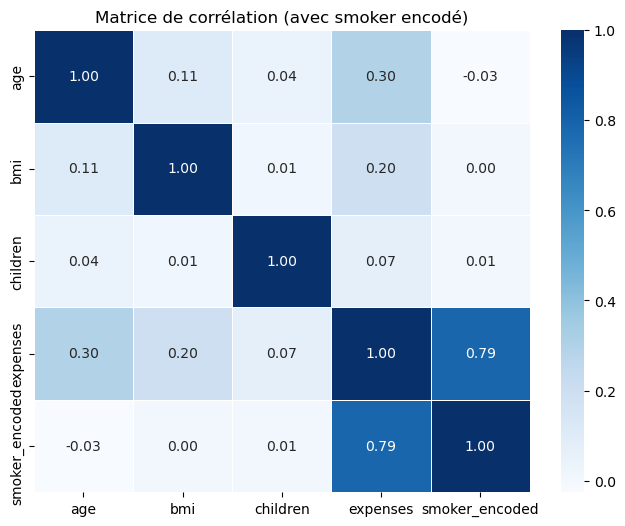

In [11]:
# On travaille sur une COPIE du DataFrame, 
# pour ne pas modifier df original.
# Une bonne pratique générale de programmation pour éviter de créer des colonnes redondantes
# (l'encodage ici est temporaire, juste pour visualiser la corrélation)
df_corr = df.copy()
# On crée une nouvelle colonne 'smoker_encoded' :
df_corr['smoker_encoded'] = df_corr['smoker'].map({'yes': 1, 'no': 0})
corr_matrix = df_corr.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title("Matrice de corrélation (avec smoker encodé)")
plt.show()

### Commentaire :
On constate une forte correlation entre les fumeurs et les frais médicaux (0.79).
L'IMC a une corrélation faible avec les frais médicaux (0.20).
Le nombre d'enfants n'a presque aucune correlation avec les frais médicaux.

# 3. Prétraitement

## 3.1 Encodage (sex, smoker, region)

### Commentaire 
Les variables catégorielles sex et smoker ont été encodées en valeurs binaires (0/1), et region a été transformée via One-Hot Encoding en 3 colonnes indicatrices (northwest, southeast, southwest), la catégorie northeast servant de référence implicite. Toutes les variables sont désormais numériques, prêtes pour la standardisation et la modélisation.

In [18]:
# On recharge le fichier depuis le CSV d'origine pour repartir de données propres :
# sex/smoker contenaient encore du texte ("male"/"female", "yes"/"no") à ce stade,
# et une exécution précédente de cette cellule avait déjà transformé ces colonnes
# en 0/1, ce qui provoquait des NaN en relançant .map() une seconde fois sur des
# valeurs déjà numériques
# df = pd.read_csv('insurance-data.csv')
# df = df.drop_duplicates()
df_copie = df.copy()


# One-Hot encoding pour région (4 catégories, sans ordre) et sex/smoker qui sont binaire
df= pd.get_dummies(df, columns=['sex','smoker','region'], drop_first=True)
df.head()

,age,bmi,children,expenses,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.9,0,16884.92,False,True,False,False,True
1,18,33.8,1,1725.55,True,False,False,True,False
2,28,33.0,3,4449.46,True,False,False,True,False
3,33,22.7,0,21984.47,True,False,True,False,False
4,32,28.9,0,3866.86,True,False,True,False,False


## 3.2 Split train et test

In [19]:
# Séparer features (X) et target (y)
X = df.drop(columns='expenses')
Y = df['expenses']

print(X.columns.tolist())
print(X.shape, Y.shape)

['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']
(1337, 8) (1337,)


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(1069, 8) (268, 8)


## 3.3 Standardisation

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Entraînement de plusieurs modèles et comparaison

## 4.1 Régression Linéaire (Zohair)

In [28]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, Y_train)
Y_pred_lr = lr.predict(X_test_scaled)

## 4.2 Random Forest (Zohair)

In [29]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_scaled, Y_train)
Y_pred_rf = rf.predict(X_test_scaled)

## 4.3 Métriques pour les deux modèles (Régression linèaire et Random Forest) (Zohair)

In [30]:
from sklearn import metrics

for nom, Y_pred in [('Régression Linéaire', Y_pred_lr), ('Random Forest', Y_pred_rf)]:
    mae = metrics.mean_absolute_error(Y_test, Y_pred)
    mse = metrics.mean_squared_error(Y_test, Y_pred)
    r2 = metrics.r2_score(Y_test, Y_pred)
    print(f"{nom} - MAE: {mae: .2f}, MSE: {mse:.2f}, R2: {r2:.3f}")

Régression Linéaire - MAE:  4177.27, MSE: 35481471.60, R2: 0.807
Random Forest - MAE:  2664.86, MSE: 22227850.25, R2: 0.879


### Commentaire 
- MAE : Random Forest se trompe en moyenne de 2665, contre 4177 pour la Régression Linéaire.
- MSE : plus faible pour Random Forest.
- R2 : Random Forest explique presque 87% de la variance des frais médicaux, contre presque 80% pour la Régression Linéaire.
- **Conclusion** : Random Forest est nettement plus performant que la Régression Linéaire sur les trois métriques (MAE, MSE, R²).

## 4.4 Analyse des erreurs sur les deux modèles (Zohair)

In [35]:
# Comparaison 

comparaison = pd.DataFrame({
    'Réel': Y_test.values,
    'Régression Linéaire' : Y_pred_lr,
    'Random Forest': Y_pred_rf
})
comparaison['Erreur_LR']= abs(comparaison['Réel'] - comparaison['Régression Linéaire'])
comparaison['Erreur_RF']= abs(comparaison['Réel'] - comparaison['Random Forest'])
comparaison.sort_values('Erreur_RF', ascending=False).head(10)

,Réel,Régression Linéaire,Random Forest,Erreur_LR,Erreur_RF
124,28340.19,9013.009831,8075.4945,19327.180169,20264.6955
14,24915.05,10805.388539,6284.8731,14109.661461,18630.1769
79,30260.00,12811.475269,12670.8087,17448.524731,17589.1913
24,55135.40,31098.113614,38505.7521,24037.286386,16629.6479
34,63770.43,39657.187160,47521.5808,24113.242840,16248.8492
175,32734.19,26271.368830,16975.5809,6462.821170,15758.6091
197,20177.67,5028.632106,4715.3791,15149.037894,15462.2909
254,60021.40,36992.896135,44640.1873,23028.503865,15381.2127
190,17878.90,8277.493465,2993.3769,9601.406535,14885.5231
242,20277.81,5970.187039,5399.2639,14307.622961,14878.5461


### Commenatire
Random Forest est globalement meilleur sur l'ensemble du jeu de test, bien que plus performant en moyenne, il n'est pas systématiquement meilleur sur tous les cas individuels, spécifiquement sur les valeurs extrêmes où la Régression Linéaire garde parfois l'avantage.

# 5. Réglage des hyperparamètres (Zohair)

In [36]:
# GridSearchCV : meilleurs paramètres trouvés
from sklearn.model_selection import GridSearchCV # teste automatiquement plusieurs combinaisons 
# de paramètres pour trouver celle qui donne la meilleure performance

param_grid = {
    'n_estimators' : [100, 200, 300], # (nombre d'arbres dans la forêt) : essayer 100, 200 ou 300
    'max_depth' : [None, 5, 10, 15] # max_depth (profondeur maximale de chaque arbre) : essayer sans limite (None), 
                                    # ou limiter à 5, 10 ou 15
}

grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring='r2')
grid_search.fit(X_train_scaled, Y_train)

print("Meilleurs paramètres:", grid_search.best_params_)
print("Meilleur score R2 (CV) :", grid_search.best_score_)

Meilleurs paramètres: {'max_depth': 5, 'n_estimators': 200}
Meilleur score R2 (CV) : 0.8427065867713178


### Commentaire 
Le réglage des hyperparamètres via GridSearchCV révèle que la meilleure combinaison est max_depth=5 et n_estimators=200, avec un score R² de presque 0.84. la profondeur optimale (5) est nettement inférieure à la profondeur par défaut illimitée (None) utilisée initialement, cela suggère qu'un Random Forest plus simple, avec des arbres moins profonds, généralise mieux sur ce dataset et limite le risque de surapprentissage. Ce résultat confirme l'intérêt du réglage des hyperparamètres pour affiner la performance du modèle au-delà des paramètres par défaut.

In [37]:
# Entraîner rf_optimise avec ces paramètres et vérifier son R² sur X_test

rf_optimise = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
rf_optimise.fit(X_train_scaled, Y_train)
y_pred_rf_optimise = rf_optimise.predict(X_test_scaled)

r2_optimise = metrics.r2_score(Y_test, y_pred_rf_optimise)
print("R² Random Forest optimisé (sur X_test) :", r2_optimise)
print("R² Random Forest initial (sur X_test)   :", metrics.r2_score(Y_test, Y_pred_rf))

R² Random Forest optimisé (sur X_test) : 0.9012932885075025
R² Random Forest initial (sur X_test)   : 0.8790361024315173


### Commentaire 
Le réglage des hyperparamètres a bien amélioré mon modèle. Random Forest optimisé devient donc le meilleur modèle identifié à ce stade en attendant de croiser mes résultat avec celui de mon binôme. 

# 6. Analyse des erreurs et sélection du modèle optimal